# Task 3 — Exploratory Data Analysis (EDA) 

**Goal:** Dig into the cleaned data to discover real patterns,
trends and relationships — before building any model.

**Real Data Scientist Mindset:**
> EDA is detective work. You're looking for answers to questions
> like: "What actually drives student performance?"
> "Are there surprising relationships?" "What will the model need to know?"
> Never skip this step — blind modelling produces blind results.

**What we'll do:**
1. Grade distributions — shape and spread
2. Correlation analysis — what predicts G3?
3. Group comparisons — failures, study time, alcohol
4. Outlier analysis — what's unusual?
5. Grade progression — do students improve over time?
6. Written findings summary

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys, os

sys.path.append('..')
from src.eda import (
    grade_statistics, correlation_analysis,
    group_analysis, outlier_report,
    grade_progression, eda_summary
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 12
CHART_DIR = '../images/charts'
os.makedirs(CHART_DIR, exist_ok=True)

print("Imports ready")

Imports ready


### Load cleaned data

In [3]:
df = pd.read_csv('../data/processed/student_clean.csv')

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Pass: {df['pass_fail'].sum()} ({df['pass_fail'].mean()*100:.1f}%)  "
      f"Fail: {(df['pass_fail']==0).sum()} ({(1-df['pass_fail'].mean())*100:.1f}%)")


Loaded: 395 rows × 38 columns
Pass: 265 (67.1%)  Fail: 130 (32.9%)


###  Grade statistics

In [4]:
stats = grade_statistics(df)

print(" Grade Statistics ")
print(f"\n{'Metric':<12}  {'G1 (Term 1)':>12}  {'G2 (Term 2)':>12}  {'G3 (Final)':>12}")
print("─" * 55)
for metric in ['mean','median','std','min','max','skew','pass_pct']:
    g1 = stats['G1'][metric]
    g2 = stats['G2'][metric]
    g3 = stats['G3'][metric]
    label = 'pass %' if metric == 'pass_pct' else metric
    print(f"{label:<12}  {str(g1):>12}  {str(g2):>12}  {str(g3):>12}")

print(f"""
💡 Insight: Grades slightly decline each term (G1→G2→G3).
   G3 is left-skewed (skew={stats['G3']['skew']}) — more students
   score in the upper range, but failures pull the left tail down.
""")

 Grade Statistics 

Metric         G1 (Term 1)   G2 (Term 2)    G3 (Final)
───────────────────────────────────────────────────────
mean                 10.91         10.71         10.42
median                11.0          11.0          11.0
std                   3.32          3.76          4.58
min                      3             0             0
max                     19            19            20
skew                 0.241        -0.432        -0.733
pass %                64.1          63.0          67.1

💡 Insight: Grades slightly decline each term (G1→G2→G3).
   G3 is left-skewed (skew=-0.733) — more students
   score in the upper range, but failures pull the left tail down.



### Plot 1: Grade distributions

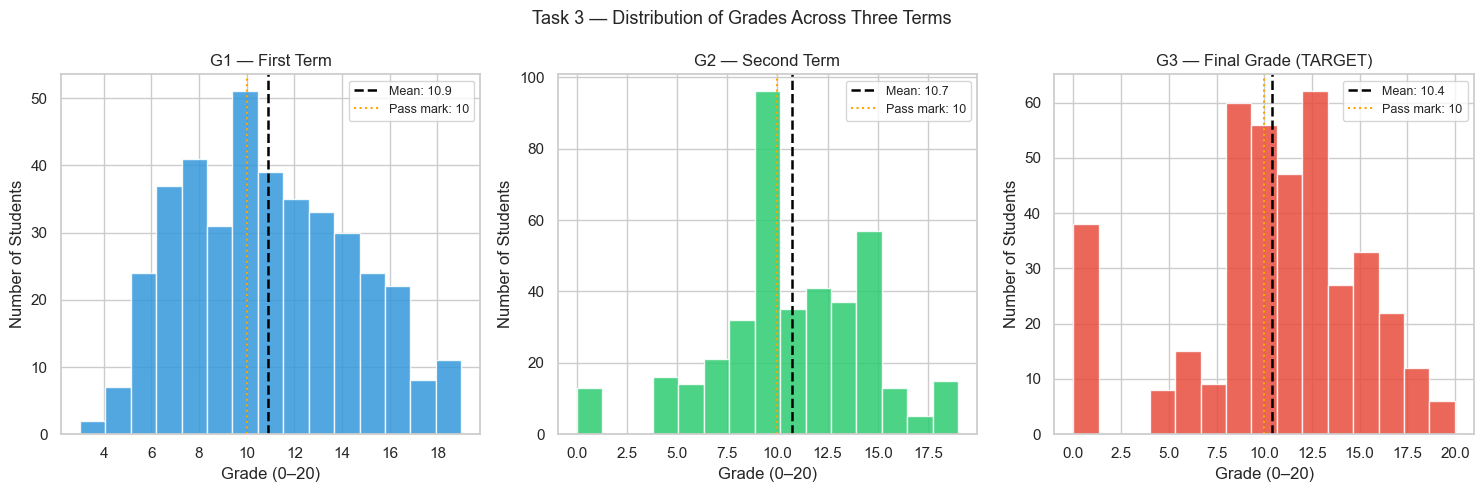

Saved: task3_grade_distributions.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
titles = ['G1 — First Term', 'G2 — Second Term', 'G3 — Final Grade (TARGET)']

for i, (col, color, title) in enumerate(zip(['G1','G2','G3'], colors, titles)):
    axes[i].hist(df[col], bins=15, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--',
                    linewidth=1.8, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(10, color='orange', linestyle=':', linewidth=1.5, label='Pass mark: 10')
    axes[i].set_title(title)
    axes[i].set_xlabel('Grade (0–20)')
    axes[i].set_ylabel('Number of Students')
    axes[i].legend(fontsize=9)

plt.suptitle('Task 3 — Distribution of Grades Across Three Terms', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_grade_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_grade_distributions.png")

## Correlation analysis
### This is the most important cell in EDA.
### Correlation tells us which features actually matter for prediction.


In [6]:
corr = correlation_analysis(df, target='G3')

print("Correlations with G3 (Final Grade) ")
print("\n TOP POSITIVE (higher value → higher G3):")
pos = corr[corr > 0].head(8)
for feat, val in pos.items():
    bar = '█' * int(abs(val) * 20)
    print(f"  {feat:<18} {val:>+.3f}  {bar}")

print("\n TOP NEGATIVE (higher value → lower G3):")
neg = corr[corr < 0].head(8)
for feat, val in neg.items():
    bar = '█' * int(abs(val) * 20)
    print(f"  {feat:<18} {val:>+.3f}  {bar}")

print(f"""
💡 Key insight: G2 (r=0.90) and G1 (r=0.80) dominate all other
   features. This means previous grades are the best predictor
   of final grades. Past failures (r=-0.36) and dropout flag
   (r=-0.42) are the strongest non-grade predictors.
""")


Correlations with G3 (Final Grade) 

 TOP POSITIVE (higher value → higher G3):
  G2                 +0.905  ██████████████████
  grade_avg_g1g2     +0.890  █████████████████
  G1                 +0.801  ████████████████
  pass_fail          +0.770  ███████████████
  Medu               +0.217  ████
  parent_edu_avg     +0.205  ████
  higher             +0.182  ███
  Fedu               +0.152  ███

 TOP NEGATIVE (higher value → lower G3):
  is_dropout         -0.420  ████████
  failures           -0.360  ███████
  age                -0.162  ███
  goout              -0.133  ██
  romantic           -0.130  ██
  traveltime         -0.117  ██
  schoolsup          -0.083  █
  guardian           -0.070  █

💡 Key insight: G2 (r=0.90) and G1 (r=0.80) dominate all other
   features. This means previous grades are the best predictor
   of final grades. Past failures (r=-0.36) and dropout flag
   (r=-0.42) are the strongest non-grade predictors.



## Correlation heatmap

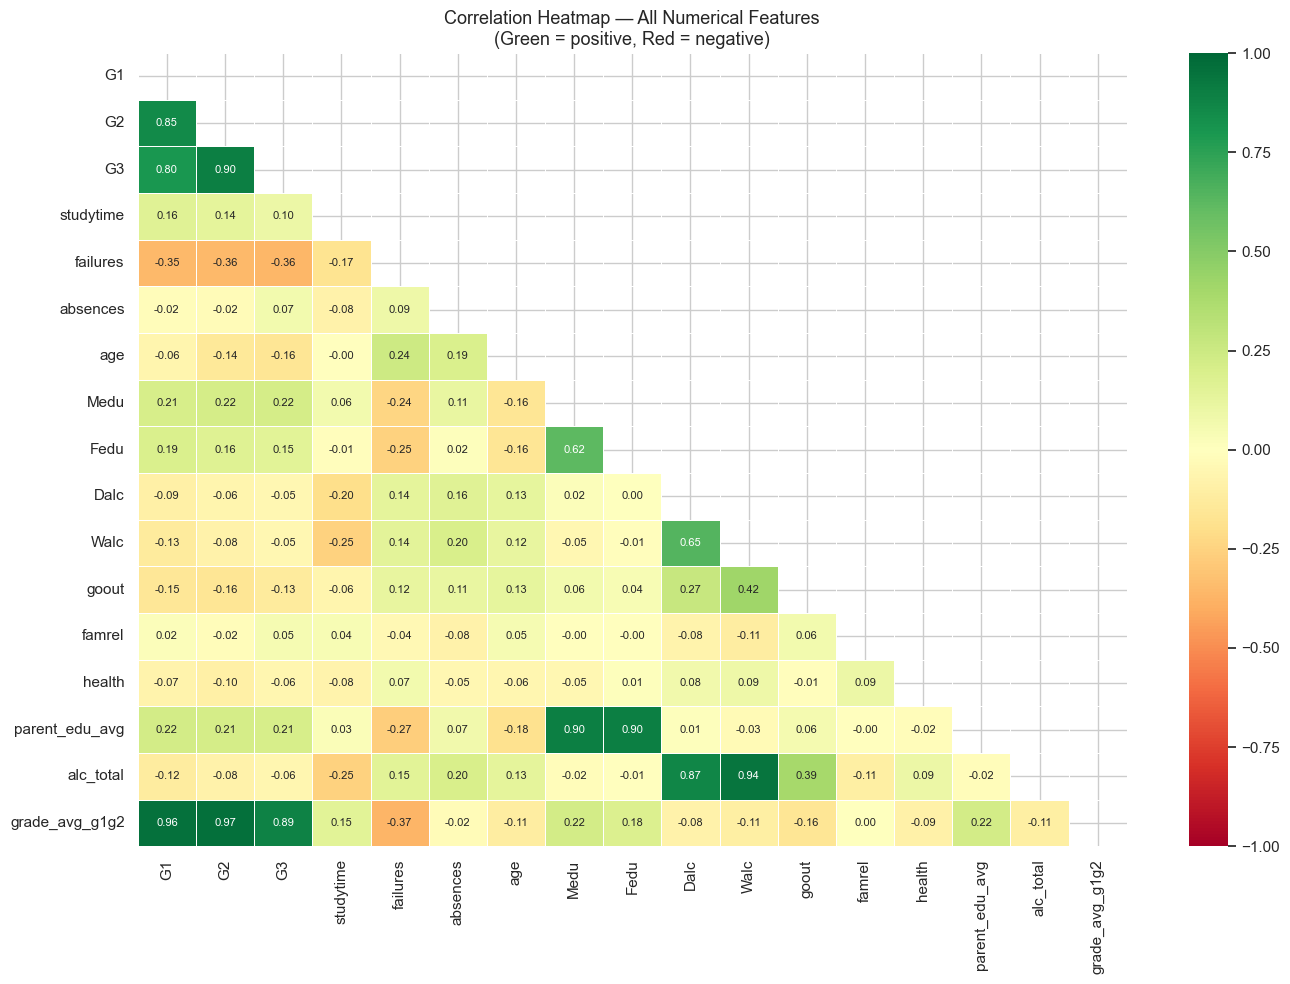

Saved: task3_correlation_heatmap.png

 Reading a heatmap: each cell shows correlation between two features.
   Dark green = strong positive, Dark red = strong negative, White = no relation.


In [7]:
num_cols = ['G1','G2','G3','studytime','failures','absences','age',
            'Medu','Fedu','Dalc','Walc','goout','famrel','health',
            'parent_edu_avg','alc_total','grade_avg_g1g2']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={'size': 8},
    linewidths=0.5,
)
ax.set_title('Correlation Heatmap — All Numerical Features\n'
             '(Green = positive, Red = negative)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_correlation_heatmap.png")
print("\n Reading a heatmap: each cell shows correlation between two features.")
print("   Dark green = strong positive, Dark red = strong negative, White = no relation.")

### Plot 3: Group comparison — failures & studytime

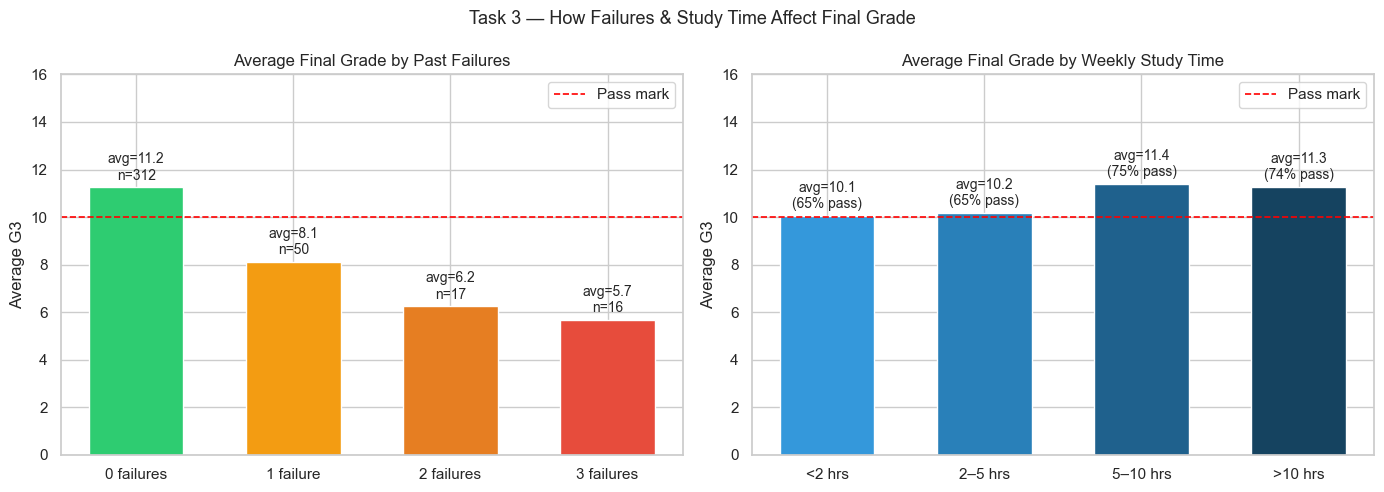

 Saved: task3_failures_studytime.png

 Insight: Each additional past failure drops the average G3 by ~2 points.
   Studying >5 hrs/week gives a +1.2 grade boost over studying <2 hrs.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: G3 by number of past failures 
fail_stats = group_analysis(df, 'failures')
bars = axes[0].bar(
    [f'{i} failure{"s" if i!=1 else ""}' for i in fail_stats.index],
    fail_stats['mean_grade'],
    color=['#2ecc71','#f39c12','#e67e22','#e74c3c'],
    edgecolor='white', width=0.6
)
for bar, (idx, row) in zip(bars, fail_stats.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"avg={row['mean_grade']:.1f}\nn={int(row['count'])}",
        ha='center', va='bottom', fontsize=10
    )
axes[0].axhline(10, color='red', linestyle='--', linewidth=1.2, label='Pass mark')
axes[0].set_title('Average Final Grade by Past Failures')
axes[0].set_ylabel('Average G3')
axes[0].set_ylim(0, 16)
axes[0].legend()

# ── Right: G3 by weekly study time 
study_labels = {1:'<2 hrs', 2:'2–5 hrs', 3:'5–10 hrs', 4:'>10 hrs'}
study_stats = group_analysis(df, 'studytime')
x_labels = [study_labels[i] for i in study_stats.index]
bars2 = axes[1].bar(
    x_labels, study_stats['mean_grade'],
    color=['#3498db','#2980b9','#1f618d','#154360'],
    edgecolor='white', width=0.6
)
for bar, (idx, row) in zip(bars2, study_stats.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"avg={row['mean_grade']:.1f}\n({row['pass_rate']:.0f}% pass)",
        ha='center', va='bottom', fontsize=10
    )
axes[1].axhline(10, color='red', linestyle='--', linewidth=1.2, label='Pass mark')
axes[1].set_title('Average Final Grade by Weekly Study Time')
axes[1].set_ylabel('Average G3')
axes[1].set_ylim(0, 16)
axes[1].legend()

plt.suptitle('Task 3 — How Failures & Study Time Affect Final Grade', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_failures_studytime.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: task3_failures_studytime.png")
print("\n Insight: Each additional past failure drops the average G3 by ~2 points.")
print("   Studying >5 hrs/week gives a +1.2 grade boost over studying <2 hrs.")


### Plot 4: Lifestyle factors

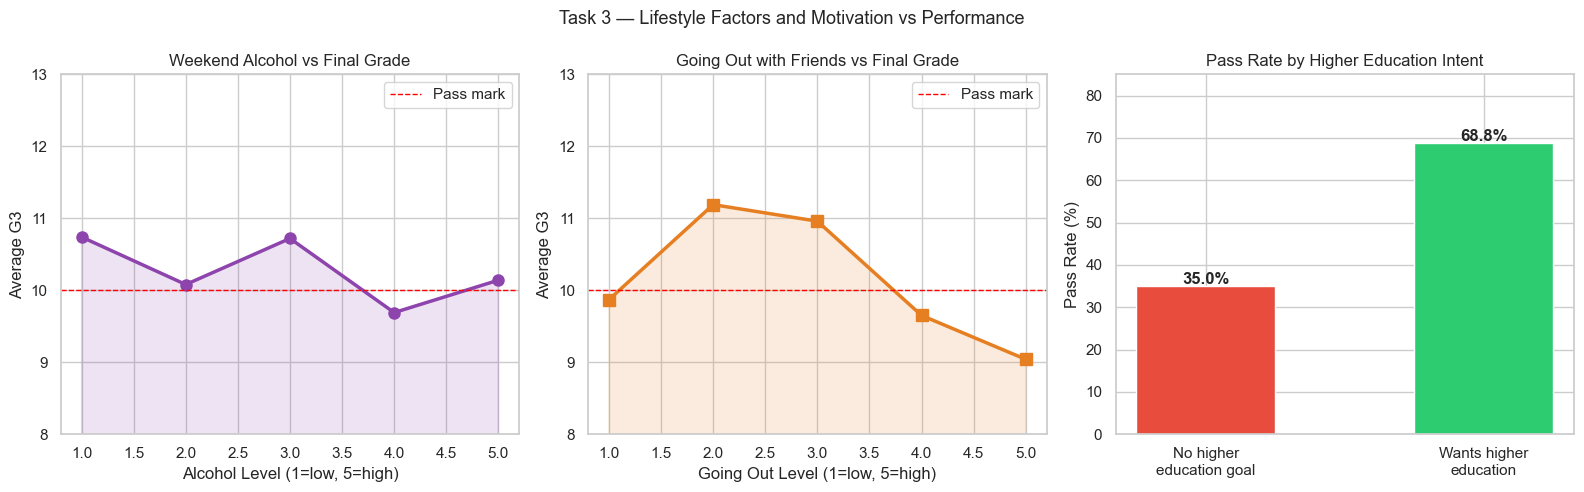

 Saved: task3_lifestyle_factors.png

 Insight: Wanting higher education nearly doubles the pass rate (35% → 69%).
   Going out frequently (level 4-5) correlates with lower grades.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  Plot A: Weekend alcohol vs G3 
walc_stats = group_analysis(df, 'Walc')
axes[0].plot(walc_stats.index, walc_stats['mean_grade'],
             marker='o', color='#8e44ad', linewidth=2.5, markersize=8)
axes[0].fill_between(walc_stats.index, walc_stats['mean_grade'],
                     alpha=0.15, color='#8e44ad')
axes[0].axhline(10, color='red', linestyle='--', linewidth=1, label='Pass mark')
axes[0].set_title('Weekend Alcohol vs Final Grade')
axes[0].set_xlabel('Alcohol Level (1=low, 5=high)')
axes[0].set_ylabel('Average G3')
axes[0].set_ylim(8, 13)
axes[0].legend()

#  Plot B: Going out vs G3 
goout_stats = group_analysis(df, 'goout')
axes[1].plot(goout_stats.index, goout_stats['mean_grade'],
             marker='s', color='#e67e22', linewidth=2.5, markersize=8)
axes[1].fill_between(goout_stats.index, goout_stats['mean_grade'],
                     alpha=0.15, color='#e67e22')
axes[1].axhline(10, color='red', linestyle='--', linewidth=1, label='Pass mark')
axes[1].set_title('Going Out with Friends vs Final Grade')
axes[1].set_xlabel('Going Out Level (1=low, 5=high)')
axes[1].set_ylabel('Average G3')
axes[1].set_ylim(8, 13)
axes[1].legend()

#  Plot C: Higher education intent 
higher_stats = group_analysis(df, 'higher')
labels = ['No higher\neducation goal', 'Wants higher\neducation']
bars = axes[2].bar(labels, higher_stats['pass_rate'],
                   color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(bars, higher_stats['pass_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Pass Rate by Higher Education Intent')
axes[2].set_ylabel('Pass Rate (%)')
axes[2].set_ylim(0, 85)

plt.suptitle('Task 3 — Lifestyle Factors and Motivation vs Performance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_lifestyle_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: task3_lifestyle_factors.png")
print("\n Insight: Wanting higher education nearly doubles the pass rate (35% → 69%).")
print("   Going out frequently (level 4-5) correlates with lower grades.")


### Plot 5: Grade progression G1 → G2 → G3

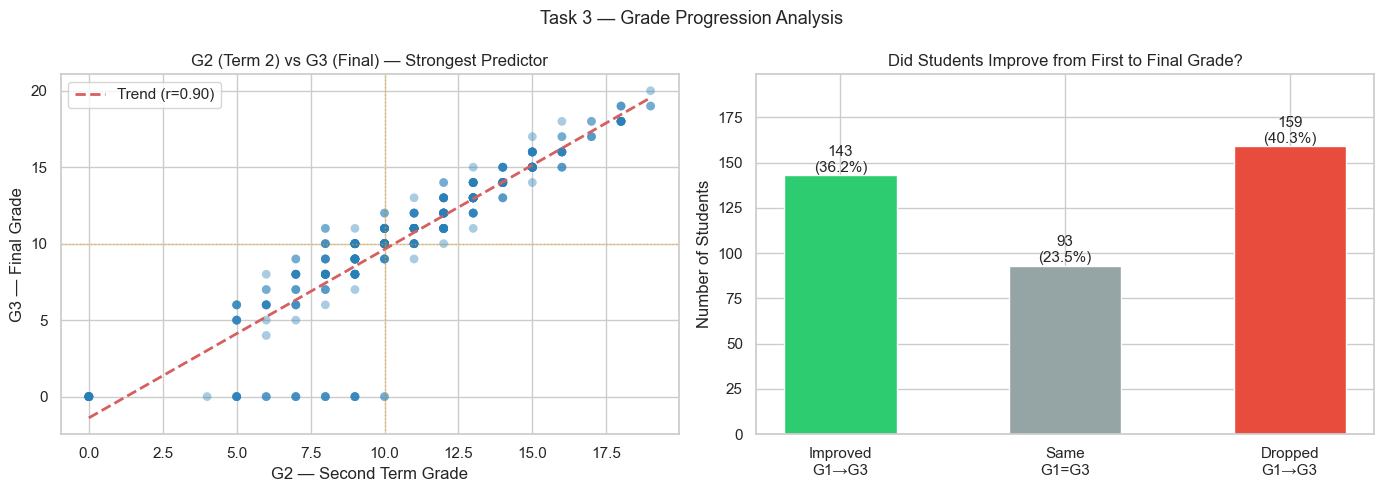

 Saved: task3_grade_progression.png

 Insight: 159 students (40.3%) dropped
   from G1 to G3. More students drop than improve — a concerning trend.


In [10]:
prog = grade_progression(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Scatter G2 vs G3 
axes[0].scatter(df['G2'], df['G3'], alpha=0.4, color='#2980b9', edgecolor='none', s=40)
# Add trend line
z = np.polyfit(df['G2'], df['G3'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['G2'].min(), df['G2'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (r=0.90)')
axes[0].axvline(10, color='orange', linestyle=':', linewidth=1, alpha=0.7)
axes[0].axhline(10, color='orange', linestyle=':', linewidth=1, alpha=0.7)
axes[0].set_title('G2 (Term 2) vs G3 (Final) — Strongest Predictor')
axes[0].set_xlabel('G2 — Second Term Grade')
axes[0].set_ylabel('G3 — Final Grade')
axes[0].legend()

# ── Right: Grade progression bar 
progression_counts = [prog['improved'], prog['same'], prog['dropped']]
progression_labels = ['Improved\nG1→G3', 'Same\nG1=G3', 'Dropped\nG1→G3']
progression_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
bars = axes[1].bar(progression_labels, progression_counts,
                   color=progression_colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, progression_counts):
    pct = count / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)
axes[1].set_title('Did Students Improve from First to Final Grade?')
axes[1].set_ylabel('Number of Students')
axes[1].set_ylim(0, max(progression_counts) * 1.25)

plt.suptitle('Task 3 — Grade Progression Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_grade_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: task3_grade_progression.png")
print(f"\n Insight: {prog['dropped']} students ({prog['dropped']/len(df)*100:.1f}%) dropped")
print(f"   from G1 to G3. More students drop than improve — a concerning trend.")

### Outlier analysis

In [11]:
print("── Outlier Report (IQR Method) ──────────────────────────────────────────")
outliers = outlier_report(df)

# Only show columns that have outliers
has_outliers = outliers[outliers['n_outliers'] > 0].sort_values('n_outliers', ascending=False)
print(f"\nColumns with outliers ({len(has_outliers)} found):")
print(has_outliers[['Q1','Q3','IQR','lower_bound','upper_bound','n_outliers','outlier_pct']].to_string())

print(f"""
 Outlier decisions:
   - failures  : 83 "outliers" — but these are valid real values (1,2,3 failures).
                 The IQR method flags them because 67% of students have 0 failures.
                 We keep all of them — failures ARE the signal, not noise.
   - absences  : already capped in Task 2 at 95th percentile.
   - studytime : similar to failures — valid values, just uncommon.
   - G2 outliers: students with G2=0 are the dropout group we already flagged.

   → No further removal needed. All outliers are real data points.
""")

── Outlier Report (IQR Method) ──────────────────────────────────────────

Columns with outliers (21 found):
              Q1    Q3  IQR  lower_bound  upper_bound  n_outliers  outlier_pct
column                                                                        
guardian     1.0   1.0  0.0          1.0          1.0         122         30.9
address      1.0   1.0  0.0          1.0          1.0          88         22.3
failures     0.0   0.0  0.0          0.0          0.0          83         21.0
nursery      1.0   1.0  0.0          1.0          1.0          81         20.5
internet     1.0   1.0  0.0          1.0          1.0          66         16.7
Mjob         2.0   3.0  1.0          0.5          4.5          59         14.9
schoolsup    0.0   0.0  0.0          0.0          0.0          51         12.9
school       0.0   0.0  0.0          0.0          0.0          46         11.6
Pstatus      1.0   1.0  0.0          1.0          1.0          41         10.4
studytime    1.0   2.0

###  Box plots for grade outliers

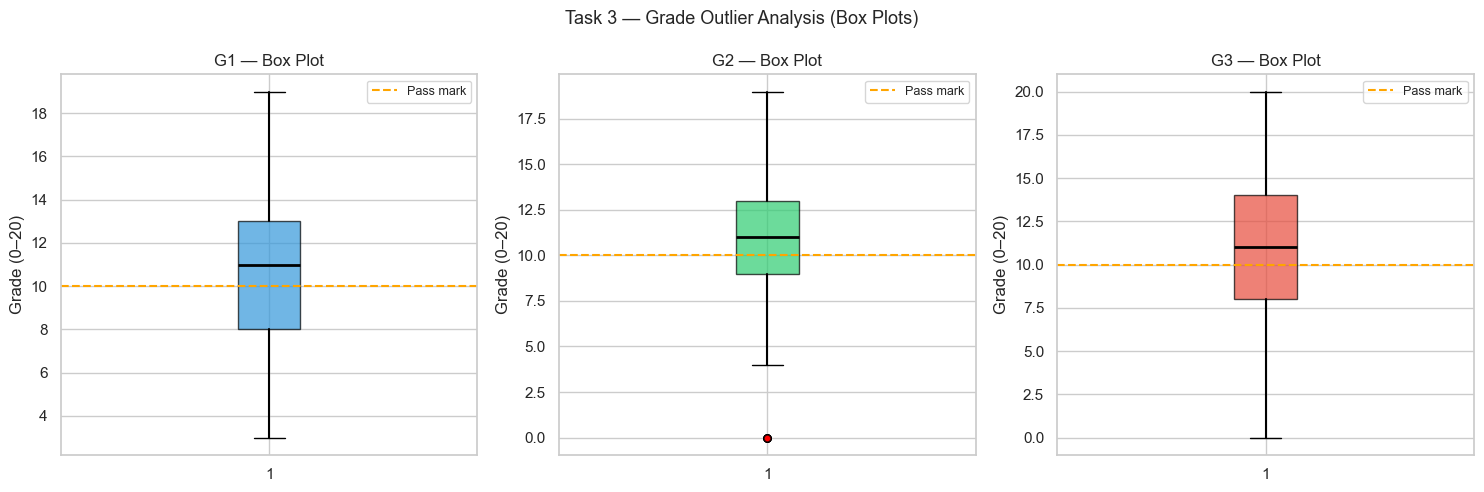

 Saved: task3_boxplots.png

 Reading box plots: the box is Q1–Q3 (middle 50%), the line is median,
   dots beyond the whiskers are outliers.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['G1', 'G2', 'G3']):
    bp = axes[i].boxplot(
        df[col],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=['#3498db','#2ecc71','#e74c3c'][i], alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6)
    )
    axes[i].axhline(10, color='orange', linestyle='--', linewidth=1.5, label='Pass mark')
    axes[i].set_title(f'{col} — Box Plot')
    axes[i].set_ylabel('Grade (0–20)')
    axes[i].legend(fontsize=9)

plt.suptitle('Task 3 — Grade Outlier Analysis (Box Plots)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: task3_boxplots.png")
print("\n Reading box plots: the box is Q1–Q3 (middle 50%), the line is median,")
print("   dots beyond the whiskers are outliers.")


### Parent education effect

── Parent Education vs Student Performance ──────────────────────────────

Mother's Education Level vs Student Grades:
  None        : avg G3=13.00  pass=66.7%  n=3  █████████████
  Primary     : avg G3=8.68  pass=57.6%  n=59  ████████
  Middle      : avg G3=9.73  pass=65.0%  n=103  █████████
  Secondary   : avg G3=10.30  pass=64.6%  n=99  ██████████
  Higher      : avg G3=11.76  pass=74.8%  n=131  ███████████


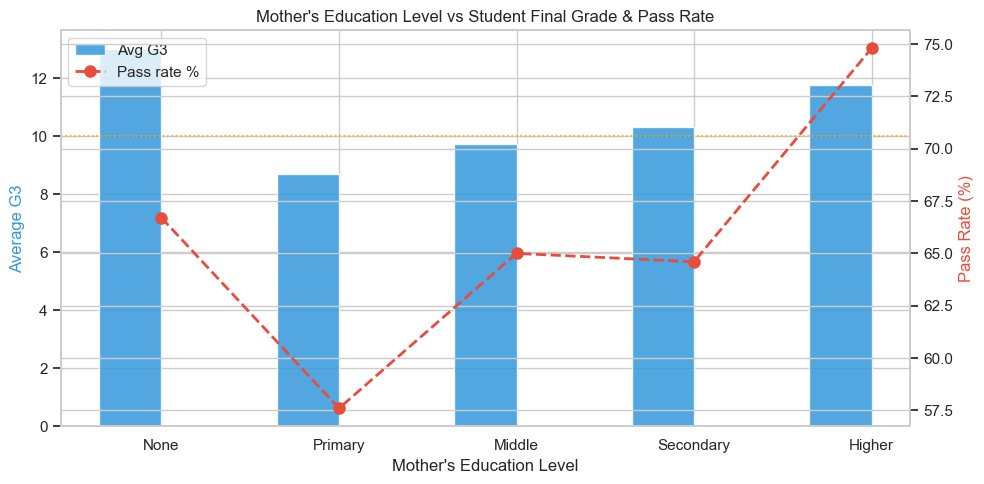


 Saved: task3_parent_education.png

 Insight: Students whose mothers have higher education
   consistently achieve better grades and higher pass rates.


In [13]:
print("── Parent Education vs Student Performance ──────────────────────────────")

medu_stats = group_analysis(df, 'Medu')
edu_labels = {0:'None', 1:'Primary', 2:'Middle', 3:'Secondary', 4:'Higher'}

print("\nMother's Education Level vs Student Grades:")
for idx, row in medu_stats.iterrows():
    bar = '█' * int(row['mean_grade'])
    print(f"  {edu_labels.get(idx, idx):<12}: avg G3={row['mean_grade']:.2f}  "
          f"pass={row['pass_rate']:.1f}%  n={int(row['count'])}  {bar}")

fig, ax = plt.subplots(figsize=(10, 5))
x = medu_stats.index
width = 0.35

bars1 = ax.bar(x - width/2, medu_stats['mean_grade'],
               width, label="Avg G3", color='#3498db', alpha=0.85, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(x, medu_stats['pass_rate'], 'o--', color='#e74c3c',
         linewidth=2, markersize=8, label='Pass rate %')

ax.set_xticks(x)
ax.set_xticklabels([edu_labels[i] for i in x])
ax.set_xlabel("Mother's Education Level")
ax.set_ylabel('Average G3', color='#3498db')
ax2.set_ylabel('Pass Rate (%)', color='#e74c3c')
ax.set_title("Mother's Education Level vs Student Final Grade & Pass Rate")
ax.axhline(10, color='orange', linestyle=':', linewidth=1.2)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_parent_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Saved: task3_parent_education.png")
print("\n Insight: Students whose mothers have higher education")
print("   consistently achieve better grades and higher pass rates.")



### EDA Summary

In [14]:
eda_summary(df)

print("\n Charts saved to images/charts/:")
charts = [
    'task3_grade_distributions.png',
    'task3_correlation_heatmap.png',
    'task3_failures_studytime.png',
    'task3_lifestyle_factors.png',
    'task3_grade_progression.png',
    'task3_boxplots.png',
    'task3_parent_education.png',
]
for c in charts:
    print(f"    {c}")


  TASK 3 SUMMARY - Exploratory Data Analysis

  Dataset
    Rows         : 395
    Columns      : 38
    Pass rate    : 67.1%
    Fail rate    : 32.9%

  Grade statistics
    G1 mean      : 10.91   (first term)
    G2 mean      : 10.71   (second term)
    G3 mean      : 10.42   (final — our target)
    Grade trend  : slightly declining each term

  Grade progression G1 → G3
    Improved     : 143 students
    Dropped      : 159 students
    Stayed same  : 93 students

  Top 5 positive correlations with G3
    G2                0.904868
grade_avg_g1g2    0.889792
G1                0.801468
pass_fail         0.770042
Medu              0.217147

  Top 5 negative correlations with G3
    is_dropout   -0.419909
failures     -0.360415
age          -0.161579
goout        -0.132791
romantic     -0.129970

  Key findings
    1. G1 and G2 are by far the strongest predictors of G3
       (r=0.80, r=0.90). Early performance matters most.
    2. Past failures strongly hurt final grades.
       0 fa